# <center>Assignment 1 2026</center>

<center>Author: Lewei Xu (23709058)</center>

## Part 1 Softmax Regression

In this task, we will implement a Softmax Regression classifier using gradient descent optimisation from scratch. The goal of the model is to classify hand-written numbers from the MNIST dataset into 1 of 10 classes (0, 1, 2, 3, 4, 5, 6, 7, 8, 9).

Softmax Regression is a generalisation of logistic regression to the multiclass case. It estimates the probability of $\mathbf{x}$ belonging to class $k$ as,

$$\hat{p}_k = \frac{\exp(s_k(\mathbf{x}))}{\sum_{j=1}^{K} \exp(s_j(\mathbf{x}))},$$

where $K$ is the total number of classes and $s_k(\mathbf{x}) = (\theta^{(k)})^{\intercal} \mathbf{x}$.

The cost function for Softmax Regression is the cross-entropy loss, which is given by,

$$J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log \left( \hat{p}_k^{(i)} \right),$$

where $y_k^{(i)}$ is the target probability that the $i^{th}$ instance belongs to class $k$. Then $\partial J / \partial \boldsymbol{\theta}^{(k)}$ is given by,

$$\frac{\partial J}{\partial \boldsymbol{\theta}^{(k)}} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{p}_k^{(i)} - y_k^{(i)} \right) \mathbf{x}^{(i)}.$$

### Step 1: Load The Dataset

In [1]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

### Step 2: Inspect The Dataset

The MNIST dataset contains 70,000 images of handwritten digits (zero to nine). The digits have been size-normalized and centered in a fixed-size image. Each image is 28x28 pixels, resulting in 784 numerical features, values ranging from 0-255 representing the grayscale intensity, and the target data consists of an integer between 0-9. (Source: https://www.openml.org/search?type=data&sort=runs&id=554&status=active)

We can verify this checking the shape and type of `X` and `y` imported above and also display some examples from the dataset

In [2]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X dtype: {X.dtype}")
print(f"y dtype: {y.dtype}")
print(f"X[:5]: {X[:5]}")
print(f"y[:5]: {y[:5]}")
print(f"Unique labels: {sorted(list(set(y)))}")

X shape: (70000, 784)
y shape: (70000,)
X dtype: int64
y dtype: object
X[:5]: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
y[:5]: ['5' '0' '4' '1' '9']
Unique labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


As we can see, there are 70,000 images and 70,000 targets, each image conists of 784 features, and each feature is a 64 bit integer. The target `y` consists of 10 classes stored as object (string) type.

### Step 3: Split Data & Inspect Split

To perform train a Softmax Classifier on this dataset, we will first split he dataset into 70% training, 15% validation and 15% for testing, then we will inspect the distribution without stratification to determine if we need to stratify the dataset.

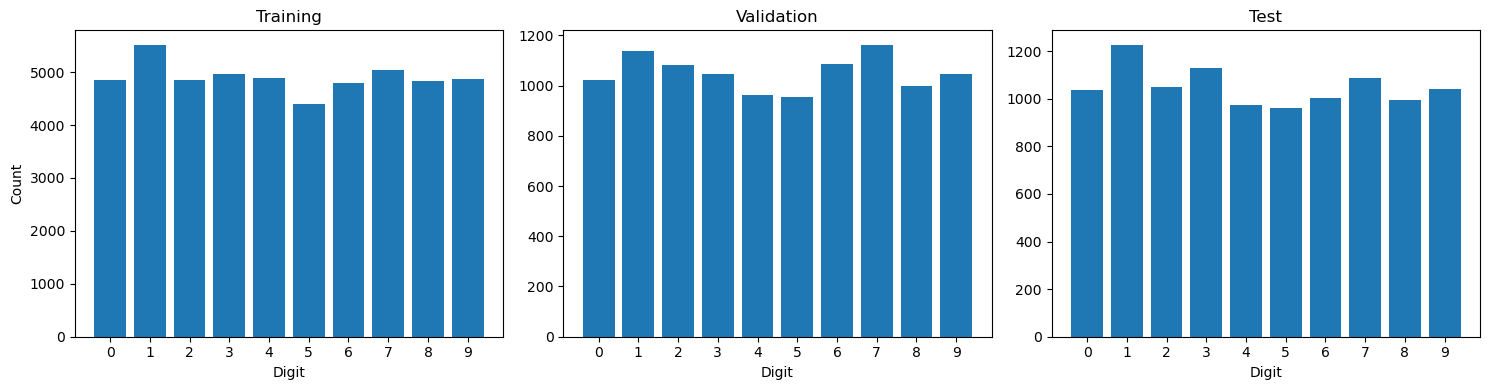

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=42)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

datasets = [("Training", y_train), ("Validation", y_val), ("Test", y_test)]

_, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, data) in enumerate(datasets):
    counts = pd.Series(data).value_counts().sort_index()

    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(name)
    axes[i].set_xlabel("Digit")

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

Although the distribution of digits (0-9) is fairly consistent, we still need to stratify the training/validation/test set to ensure that the distribution of target classes in the splits are the same proportion as the original dataset. This is done to prevent bias due to skewed data, or being trained and tested on data that isn't representative of the original data. It also results in more reliable performance metrics. We will now re-initialize the training/validation/test split with stratification.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=42, stratify=y_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (49000, 784)
X_val shape: (10500, 784)
X_test shape: (10500, 784)


### Step 4: Implement Softmax Regression From Scratch

We will now implement the softmax regression classifier from scratch to classify the hand-written numbers. We will use early stopping based on the validation set: stop training when the validation loss stops decreasing. The task sheet did not specify what form of early stopping to use (simply stop when validation loss stops decreasing, or implement patience with best model saving). To be safe, we will implement a more sophisticated patience mechanism and best model saving, with default patience = 10 epochs.

In [5]:
class SoftmaxRegressionGD:
    def __init__(self, lr=0.1, epochs=500, patience=10, display_interval=50):
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.display_interval = display_interval
        self.theta = None
        self.best_theta = None
        self.history = {'train_loss': [], 'val_loss': []}

    def softmax(self, x):
        # Should work due to scaling of inputs to 0-1
        return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

    def loss(self, y_true, y_probs):
        m = y_true.shape[0]
        return (-1/m) * np.sum(y_true * np.log(y_probs))

    def gradient(self, X, y_true, y_probs):
        m = X.shape[0]
        return (1/m) * X.T @ (y_probs - y_true)

    def one_hot_encode(self, y, num_classes):
        y = y.astype(int)
        return np.eye(num_classes)[y]
    
    def predict(self, X):
        X_bias = np.insert(X, 0, 1, axis=1)
        probs = self.softmax(X_bias @ self.best_theta)
        return np.argmax(probs, axis=1)

    def train(self, X_train, y_train, X_val, y_val):
        # Initialize theta with zeros with X_train & y_train dimensions
        self.theta = np.zeros((X_train.shape[1] + 1, len(set(y_train))))

        # Initialize training data
        X_train_bias = np.insert(X_train, 0, 1, axis=1)
        X_val_bias = np.insert(X_val, 0, 1, axis=1)
        Y_train_ohe = self.one_hot_encode(y_train, self.theta.shape[1])
        Y_val_ohe = self.one_hot_encode(y_val, self.theta.shape[1])
        
        # Initialize early stopping & history variables
        best_loss = np.infty
        epochs_without_improvement = 0

        # Begin training loop
        for epoch in range(self.epochs):
            logits = X_train_bias @ self.theta

            train_probs = self.softmax(logits)
            train_loss = self.loss(Y_train_ohe, train_probs)

            val_probs = self.softmax(X_val_bias @ self.theta)
            val_loss = self.loss(Y_val_ohe, val_probs)

            gradient = self.gradient(X_train_bias, Y_train_ohe, train_probs)
            self.theta -= self.lr * gradient

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            
            # Early stopping check
            if val_loss < best_loss:
                best_loss = val_loss
                self.best_theta = self.theta.copy()
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                
            if epochs_without_improvement >= self.patience:
                print(f"Epochs without improvement reached {self.patience}. Best Val Loss: {best_loss:.4f}")
                break
                
            if epoch % self.display_interval == 0:
                print(f"Epoch {epoch}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")

`SoftmaxRegressionGD` is defined above. We will now train a model using the defined class. To ensure consistent feature contribution and optimization efficiency, we will first scale the `X` features to between 0-1. As we are performing Softmax Regression GD from scratch, we will also avoid using sklearn for scaling, and manually scale the features instead.

In [6]:
range_val = np.max(X_train) - np.min(X_train)
X_train_scaled = X_train / range_val
X_val_scaled = X_val / range_val
X_test_scaled = X_test / range_val

custom_model = SoftmaxRegressionGD() # Initialize with default parameters

custom_model.train(X_train_scaled, y_train, X_val_scaled, y_val)

Epoch 0: Train Loss 2.3026 | Val Loss 2.3026
Epoch 50: Train Loss 0.7906 | Val Loss 0.7994
Epoch 100: Train Loss 0.6036 | Val Loss 0.6138
Epoch 150: Train Loss 0.5275 | Val Loss 0.5385
Epoch 200: Train Loss 0.4844 | Val Loss 0.4961
Epoch 250: Train Loss 0.4559 | Val Loss 0.4682
Epoch 300: Train Loss 0.4354 | Val Loss 0.4481
Epoch 350: Train Loss 0.4197 | Val Loss 0.4329
Epoch 400: Train Loss 0.4071 | Val Loss 0.4208
Epoch 450: Train Loss 0.3968 | Val Loss 0.4110


Before we jump in to plotting the training and validation loss, let's first check the model's various performance metrics (what is a machine learning task without checking the accuracy of the model am I right). As this isn't exactly a part of the assignment task, we will just cheat a little bit and use sklearn's `classification_report`.

In [7]:
from sklearn.metrics import classification_report

y_pred = custom_model.predict(X_test_scaled)
y_test_int = y_test.astype(int)
print(classification_report(y_test_int, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1035
           1       0.92      0.96      0.94      1181
           2       0.91      0.85      0.88      1049
           3       0.87      0.87      0.87      1071
           4       0.90      0.90      0.90      1024
           5       0.85      0.82      0.84       947
           6       0.93      0.94      0.93      1032
           7       0.92      0.91      0.91      1094
           8       0.84      0.83      0.84      1024
           9       0.85      0.87      0.86      1043

    accuracy                           0.89     10500
   macro avg       0.89      0.89      0.89     10500
weighted avg       0.89      0.89      0.89     10500



Let's now plot the training and validation loss changes over time for the model and see what we observe.

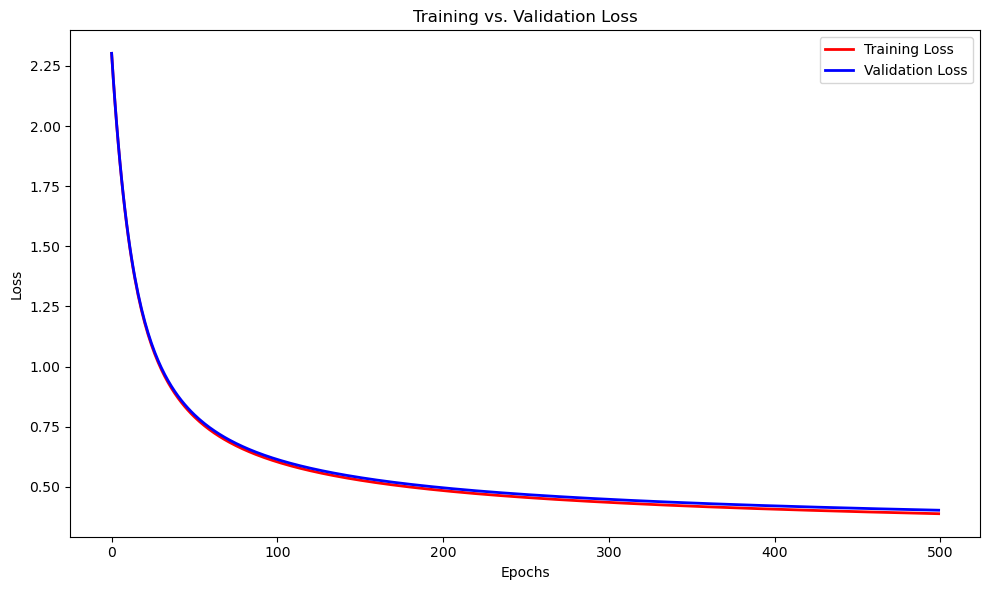

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_run = range(len(custom_model.history['train_loss']))
plt.plot(epochs_run, custom_model.history['train_loss'], label='Training Loss', color='red', linewidth=2)
plt.plot(epochs_run, custom_model.history['val_loss'], label='Validation Loss', color='blue', linewidth=2)

plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Observations**
- Both the training and validation loss curves show a smooth rapid decline in the early epochs before flattening out.
- Shape of the curve is similar to logarithmic decay, which I believe is exactly what we want for gradient descent (GD worked very well).
- Validation loss is consistently higher than training loss (although not by a significant margin).

**Expected?**
- The smoorth logarithmic curve is to be expected especially after the feature scaling to ensure the cost function is a smooth bowl shape.
- We are also using full gradient descent (not SDD or batch-GD) so we won't expect to see any jumps in loss during training.
- Validation loss is expected to be higher than training loss as the model is trying to predict unseen data.

### Step 5: Implement Softmax Regression Using `sklearn`

We will now implement the same model as above but using sklearn and compare the performance between the two. From the plot above, we can see that training and validation loss flattens out at around the 300th epoch.  We will attempt to usee similar settings for sklearn's `LogisticRegression` compared to the custom Softmax Regression by setting `max_iter=500`, and no regularisation `penalty=None`.

In [9]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(penalty=None, max_iter=500, random_state=42)

sk_model.fit(X_train_scaled, y_train)

/home/lingwei/miniconda3/envs/cits5508/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=500, penalty=None, random_state=42)

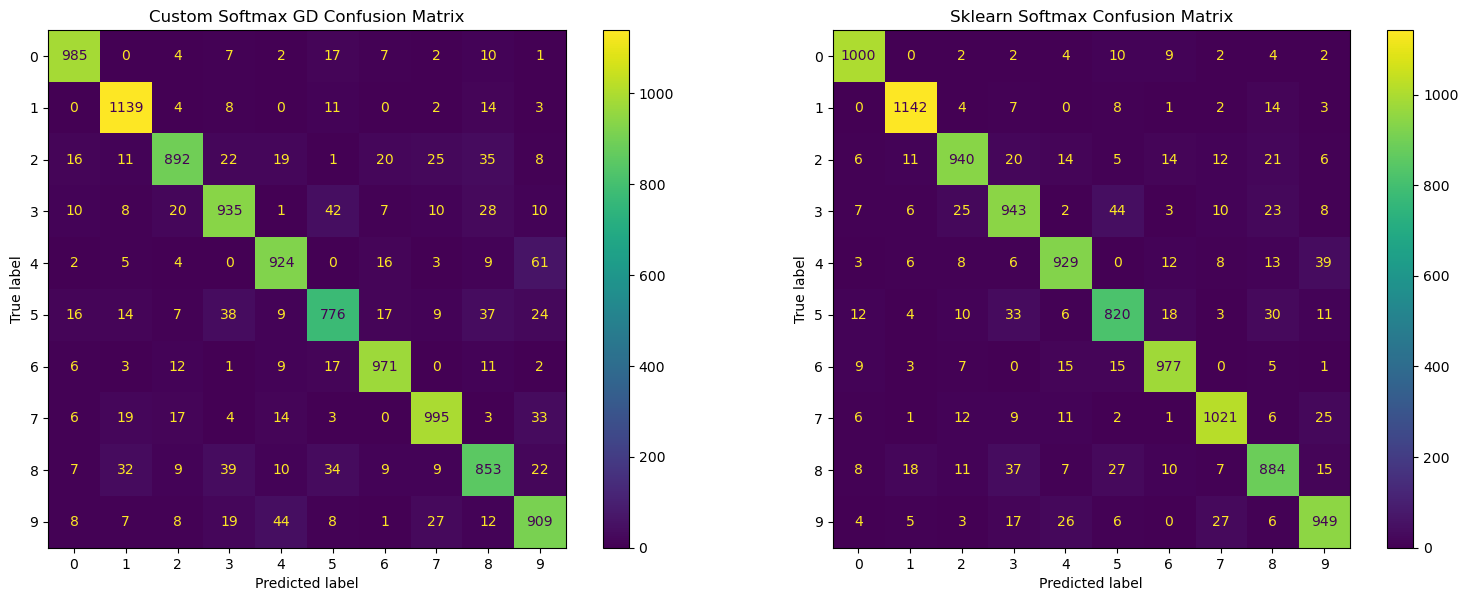

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_sk = sk_model.predict(X_test_scaled)
y_pred_custom = custom_model.predict(X_test_scaled)

y_test_int = y_test.astype(int)
y_pred_sk = y_pred_sk.astype(int)
y_pred_custom = y_pred_custom.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred_custom, ax=axes[0])
axes[0].set_title("Custom Softmax GD Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred_sk, ax=axes[1])
axes[1].set_title("Sklearn Softmax Confusion Matrix")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

report_custom = classification_report(y_test_int, y_pred_custom)
report_sk = classification_report(y_test_int, y_pred_sk)

lines_custom = report_custom.split('\n')
lines_sk = report_sk.split('\n')

header_custom = "Custom Softmax Regression GD Model"
header_sk = "Sklearn Logistic Regression Model"
print(f"{header_custom:<55} | {header_sk}")
print("-" * 115)

for c, s in zip(lines_custom, lines_sk):
    print(f"{c.ljust(55)} | {s}")

Custom Softmax Regression GD Model                      | Sklearn Logistic Regression Model
-------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support   |               precision    recall  f1-score   support
                                                        | 
           0       0.93      0.95      0.94      1035   |            0       0.95      0.97      0.96      1035
           1       0.92      0.96      0.94      1181   |            1       0.95      0.97      0.96      1181
           2       0.91      0.85      0.88      1049   |            2       0.92      0.90      0.91      1049
           3       0.87      0.87      0.87      1071   |            3       0.88      0.88      0.88      1071
           4       0.90      0.90      0.90      1024   |            4       0.92      0.91      0.91      1024
           5       0.85      0.82      0.84       947   |    

**Results**
- Both models performed very well, correctly classifying approximately 90% of images. 
- Both models struggled and performed well on the same digits: 
    - Both models performed better on "easy" digits such as 0, 1, 2, 4, 6, 7, with all metrics (precision, recall, f1-score) achieving >0.9.
    - Both performed worse on "harder" digits such as 5, 8 and 9, with precision, recall and f1-score ranging between 0.84-0.88.
    - This is to be expected, as "harder" digits like 5, 8 and 9 are very similar in structure, and it is easy for a relatively simple model like Softmax Regression to confuse them.
    - Some classifcations may not entirely be the model's fault, as some handwritten images are so deformed that even a human may have difficulty classifying them.
- In both models, precision and recall are very similar (balanced) with a macro average of 0.89 and 0.91 for the custom Softmax Regression and sklearn Logistic Regression respectively
    - This means both models aren't biased towards a specific digits.
    - Is this expected? Well, due to the statification performed when splitting the dataset into train, validation and test sets, as well as the nature of softmax itself where the total probability must sum to 1, this result should be highly expected.

We will discuss differences in the model next.

### Step 6: Conclusion & Comments

- The sklearn model slightly outperforms the custom GD model in terms of accuracy. 
    - This is to be expected, as sklearn utilizes the `lbdgs` solver which is a second order optimizer, as well as various other optimizations to basic Softmax Regression.
- As discussed above, both models perform better on "easy" digits and worse on "hard" digits, although the sklearn logistic regression model performs marginally better in both scenarios.
    - As both models are using softmax regression, this similarity is expected.
- Both models maintain a high degree of balance between precision and recall, with little bias towards specific target classes.

## Part 2: Support Vector Machine Regression

In this task, we will investigate how different kernels affect the performance of Support Vecotr Machine (SVM) regression on a synthetic dataset. We will generate our own toy datasets using polynomial functions, then fit SVM regression models with different kernels to the data.

### Part 1: Function To Generate Toy Datasets

First, we will create a function that can generate a random toy *n-degree* polynomial dataset of the form:

$$y = \sum_{k=0}^{n} a_k x^k + \epsilon,$$

where $x \in [-3, 3]$, $a_k \sim \mathcal{U}(0, 1)$, and $\epsilon \sim \mathcal{N}(0, 1)$. The function will take 2 arguments: `degree` and `n_samples=1000`.

In [ ]:
def generate_toy_dataset(degree, n_samples):

    np.random.seed(42)

    x = np.random.uniform(-3, 3, n_samples)
    a_k = np.random.uniform(0, 1, degree + 1)
    y_true = np.array([0.0] * n_samples)

    for k in range(degree + 1):
        y_true += a_k[k] * (x ** k)

    epsilon = np.random.normal(0, 1, n_samples)
    y = y_true + epsilon
    
    return x, y

Next, let's test the function by constructing 4 plots for degrees 1, 2, 3 and 5.

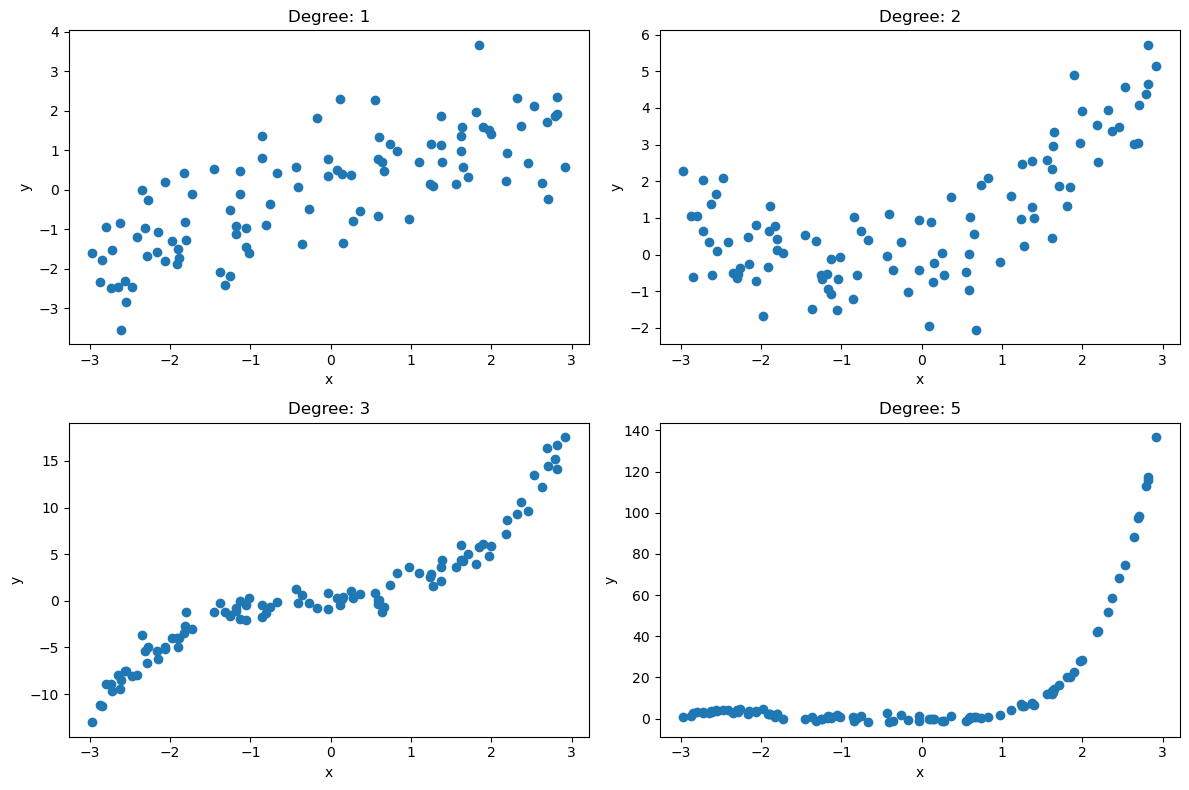

In [ ]:
def plot_dataset(degrees_to_test, samples=100):
    plt.figure(figsize=(12, 8))
    
    for i, d in enumerate(degrees_to_test):
        x, y = generate_toy_dataset(degree=d, n_samples=samples)
        
        plt.subplot(2, 2, i + 1)
        plt.scatter(x, y)
        plt.title(f'Degree: {d}')
        plt.xlabel('x')
        plt.ylabel('y')

    plt.tight_layout()
    plt.show()

plot_dataset(degrees_to_test=[1, 2, 3, 5])